### 03 - Exploratory Data Analysis

Explore the cleaned SDSS datasets before modeling.

Main questions:
- Do STAR, GALAXY, and QSO objects show different magnitude/color patterns?
- Are color indices useful for separating object classes?
- What does the galaxy redshift distribution look like?
- Is `zErr` clean enough, or should it be filtered later?

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
  PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

CLEAN_PATH = PROCESSED_DIR / "sdss_clean.csv"
GALAXY_PATH = PROCESSED_DIR / "sdss_galaxy_redshift.csv"

CLEAN_PATH, GALAXY_PATH

(WindowsPath('c:/uni/seriousism/Redshifted/data/processed/sdss_clean.csv'),
 WindowsPath('c:/uni/seriousism/Redshifted/data/processed/sdss_galaxy_redshift.csv'))

In [3]:
df = pd.read_csv(CLEAN_PATH)
df_galaxy = pd.read_csv(GALAXY_PATH)

df.shape, df_galaxy.shape

((150000, 18), (49402, 18))

In [4]:
df.head()

,objID,specObjID,ra,dec,object_class,z,zErr,zWarning,dered_u,dered_g,dered_r,dered_i,dered_z,source_file,u_g,g_r,r_i,i_z
0,1237655499736154698,3.829569e+17,198.98194,-1.754536,GALAXY,0.537970,0.000171,0,23.57166,21.05997,19.40754,18.40446,17.84912,Skyserver_SQL7_Galaxy_50k.csv,2.51169,1.65243,1.00308,0.55534
1,1237650762398826607,3.829575e+17,198.88858,-1.808939,GALAXY,0.120826,0.000010,0,18.79226,17.73469,17.16575,16.85046,16.62631,Skyserver_SQL7_Galaxy_50k.csv,1.05757,0.56894,0.31529,0.22415
2,1237655495977599096,3.829577e+17,198.88278,-1.570008,GALAXY,0.140336,0.000030,0,20.35433,18.19150,17.12941,16.66815,16.31438,Skyserver_SQL7_Galaxy_50k.csv,2.16283,1.06209,0.46126,0.35377
3,1237655499736154685,3.829580e+17,198.97587,-1.796720,GALAXY,0.488258,0.000125,0,22.18442,20.92320,19.10797,18.23481,17.80382,Skyserver_SQL7_Galaxy_50k.csv,1.26122,1.81523,0.87316,0.43099
4,1237655495977599150,3.829583e+17,198.96910,-1.571374,GALAXY,0.131105,0.000021,0,19.21795,17.49209,16.54273,16.11701,15.81184,Skyserver_SQL7_Galaxy_50k.csv,1.72586,0.94936,0.42572,0.30517


In [5]:
df_galaxy.head()

,objID,specObjID,ra,dec,object_class,z,zErr,zWarning,dered_u,dered_g,dered_r,dered_i,dered_z,source_file,u_g,g_r,r_i,i_z
0,1237655499736154698,3.829569e+17,198.98194,-1.754536,GALAXY,0.537970,0.000171,0,23.57166,21.05997,19.40754,18.40446,17.84912,Skyserver_SQL7_Galaxy_50k.csv,2.51169,1.65243,1.00308,0.55534
1,1237650762398826607,3.829575e+17,198.88858,-1.808939,GALAXY,0.120826,0.000010,0,18.79226,17.73469,17.16575,16.85046,16.62631,Skyserver_SQL7_Galaxy_50k.csv,1.05757,0.56894,0.31529,0.22415
2,1237655495977599096,3.829577e+17,198.88278,-1.570008,GALAXY,0.140336,0.000030,0,20.35433,18.19150,17.12941,16.66815,16.31438,Skyserver_SQL7_Galaxy_50k.csv,2.16283,1.06209,0.46126,0.35377
3,1237655499736154685,3.829580e+17,198.97587,-1.796720,GALAXY,0.488258,0.000125,0,22.18442,20.92320,19.10797,18.23481,17.80382,Skyserver_SQL7_Galaxy_50k.csv,1.26122,1.81523,0.87316,0.43099
4,1237655495977599150,3.829583e+17,198.96910,-1.571374,GALAXY,0.131105,0.000021,0,19.21795,17.49209,16.54273,16.11701,15.81184,Skyserver_SQL7_Galaxy_50k.csv,1.72586,0.94936,0.42572,0.30517


In [6]:
df.columns.tolist()

['objID',
 'specObjID',
 'ra',
 'dec',
 'object_class',
 'z',
 'zErr',
 'zWarning',
 'dered_u',
 'dered_g',
 'dered_r',
 'dered_i',
 'dered_z',
 'source_file',
 'u_g',
 'g_r',
 'r_i',
 'i_z']

In [7]:
df_galaxy.columns.tolist()

['objID',
 'specObjID',
 'ra',
 'dec',
 'object_class',
 'z',
 'zErr',
 'zWarning',
 'dered_u',
 'dered_g',
 'dered_r',
 'dered_i',
 'dered_z',
 'source_file',
 'u_g',
 'g_r',
 'r_i',
 'i_z']

In [8]:
class_counts = df["object_class"].value_counts()
class_counts

object_class
GALAXY    50000
QSO       50000
STAR      50000
Name: count, dtype: int64

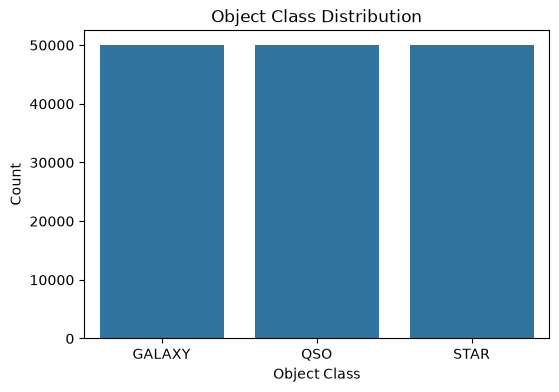

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="object_class", order=class_counts.index)
plt.title("Object Class Distribution")
plt.xlabel("Object Class")
plt.ylabel("Count")
plt.show()

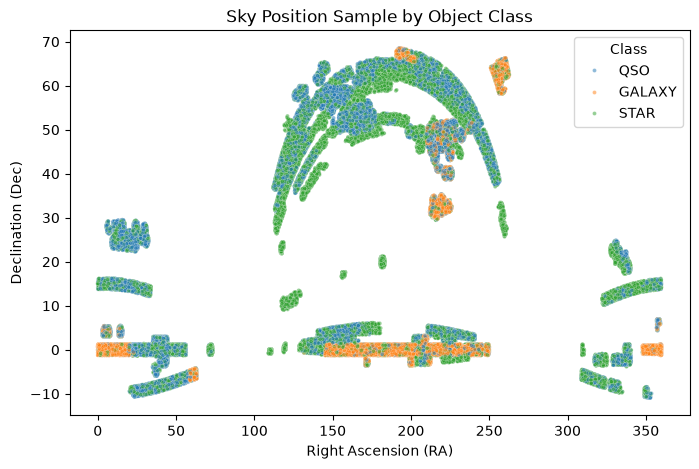

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df.sample(150000, random_state=42),
    x="ra",
    y="dec",
    hue="object_class",
    alpha=0.5,
    s=8
)

plt.title("Sky Position Sample by Object Class")
plt.xlabel("Right Ascension (RA)")
plt.ylabel("Declination (Dec)")
plt.legend(title="Class")
plt.show()

##### Explanation
The scatter shows non-uniform, striped sky coverage, which reflects the SDSS
survey footprint rather than the physical distribution of objects in space.
All three classes appear across similar sky regions, so RA/Dec are useful for
understanding survey coverage, but they are not treated as core modeling
features for now.

##### Notes:
Magnitude is inverted compared to everyday brightness intuition: a smaller
value means a brighter object. The `dered_*` columns are dereddened, meaning
they are already corrected for interstellar dust extinction.

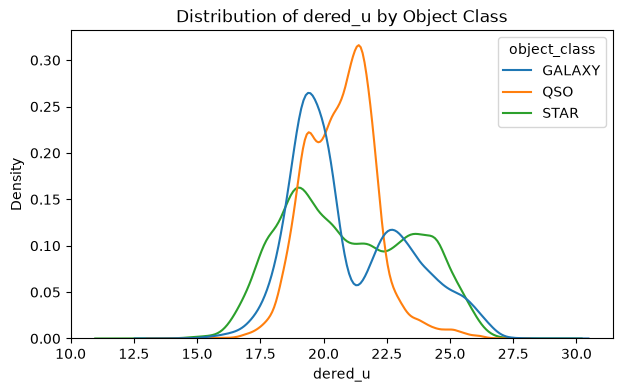

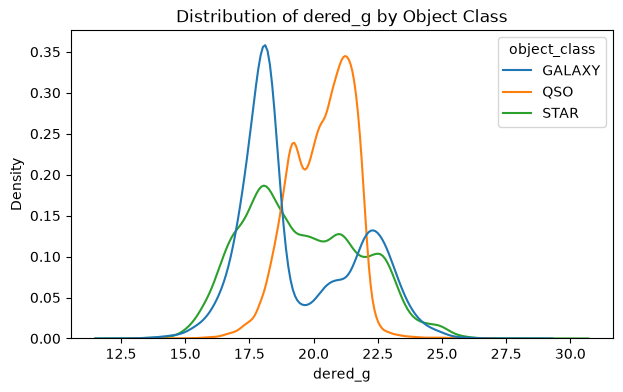

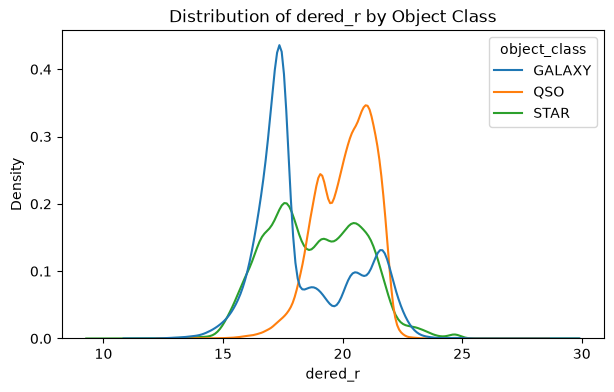

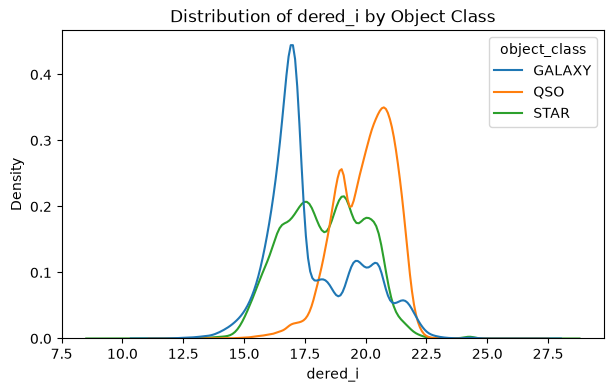

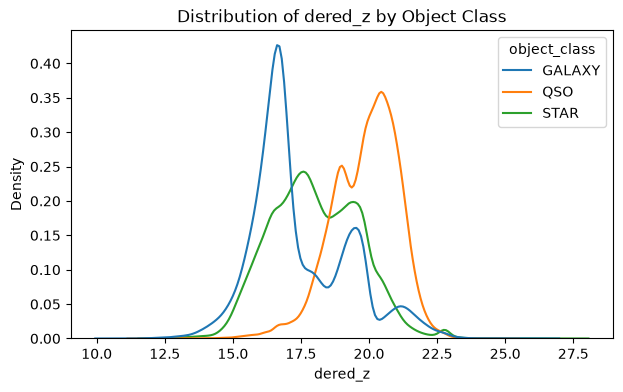

In [31]:
mag_cols = ["dered_u", "dered_g", "dered_r", "dered_i", "dered_z"]

for col in mag_cols:
  plt.figure(figsize=(7, 4))
  sns.kdeplot(data=df, x=col, hue="object_class", common_norm=False)
  plt.title(f"Distribution of {col} by Object Class")
  plt.xlabel(col)
  plt.ylabel("Density")
  plt.show()

##### Explanation
Across all five filters, QSO shows a narrow, well-centered distribution, GALAXY
peaks progressively brighter (lower magnitude) toward redder filters, and STAR
is bimodal, likely reflecting a mix of stellar types. Separation between GALAXY
and QSO improves in redder filters, but overlap remains substantial in raw
magnitude alone.

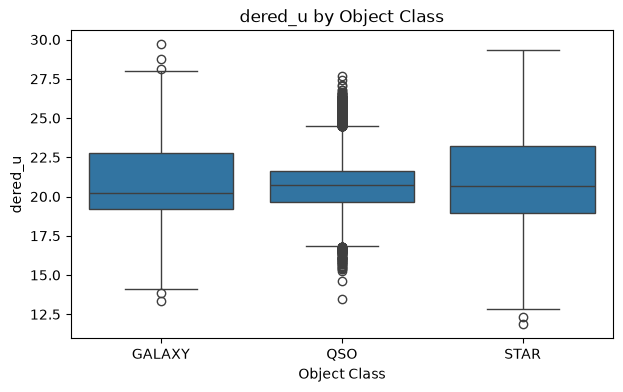

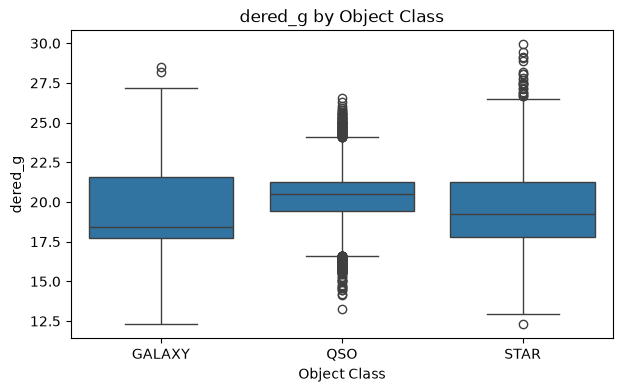

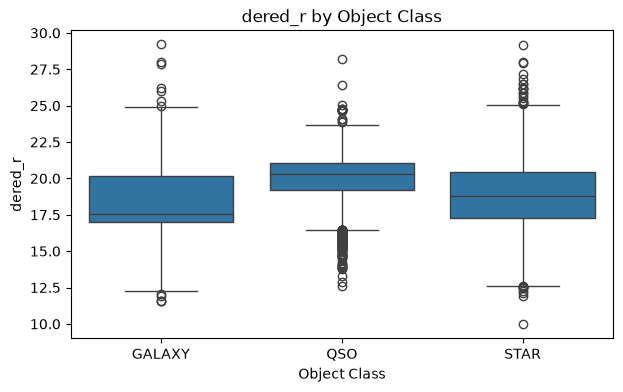

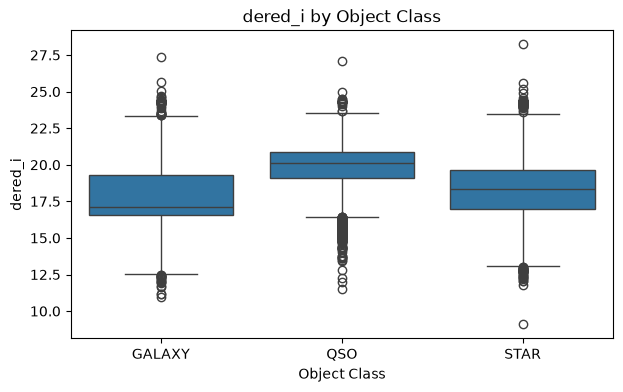

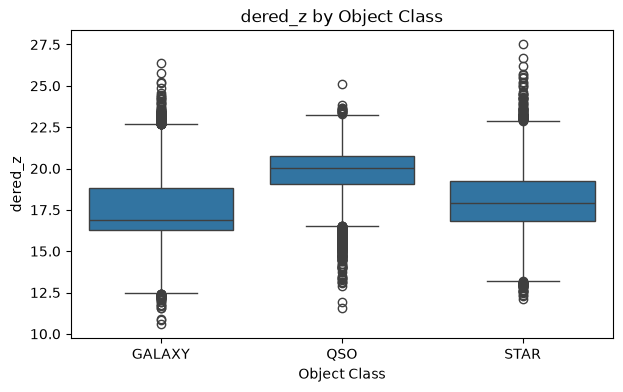

In [12]:
mag_cols = ["dered_u", "dered_g", "dered_r", "dered_i", "dered_z"]

for col in mag_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="object_class", y=col)
    plt.title(f"{col} by Object Class")
    plt.xlabel("Object Class")
    plt.ylabel(col)
    plt.show()

##### Explanation

QSO magnitudes cluster tightly around a narrow range with many individual
outliers beyond the whiskers, consistent with survey selection effects on
quasar detectability. GALAXY and STAR show wider interquartile ranges,
reflecting more natural variation in distance and intrinsic brightness.

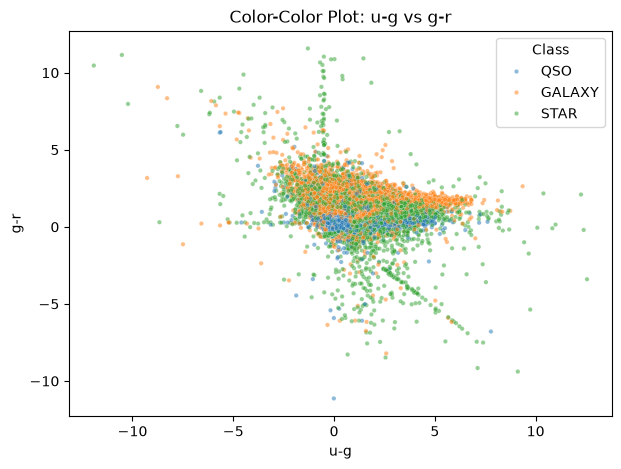

In [13]:
sample_df = df.sample(150000, random_state=42)

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=sample_df,
    x="u_g",
    y="g_r",
    hue="object_class",
    alpha=0.5,
    s=10
)
plt.title("Color-Color Plot: u-g vs g-r")
plt.xlabel("u-g")
plt.ylabel("g-r")
plt.legend(title="Class")
plt.show()

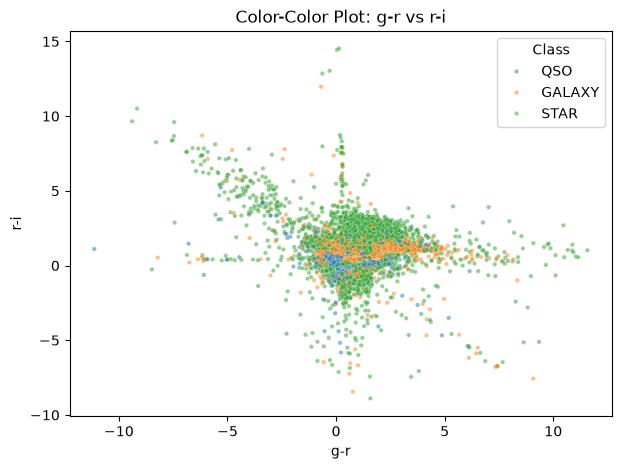

In [14]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=sample_df,
    x="g_r",
    y="r_i",
    hue="object_class",
    alpha=0.5,
    s=10
)
plt.title("Color-Color Plot: g-r vs r-i")
plt.xlabel("g-r")
plt.ylabel("r-i")
plt.legend(title="Class")
plt.show()

##### Explanation
The raw scatter plot above shows heavy overlap between classes, but with
~150k overlaid points this could simply be overplotting hiding the real
density pattern. To check, the same color space is re-examined using kernel
density estimation, which reveals where each class is actually concentrated
regardless of point overlap.
The same overplotting concern applies to the g-r vs r-i scatter, so density
estimation is used again to check whether class separation is hidden beneath
overlapping points.

In [15]:
density_sample = df.sample(75000, random_state=42)

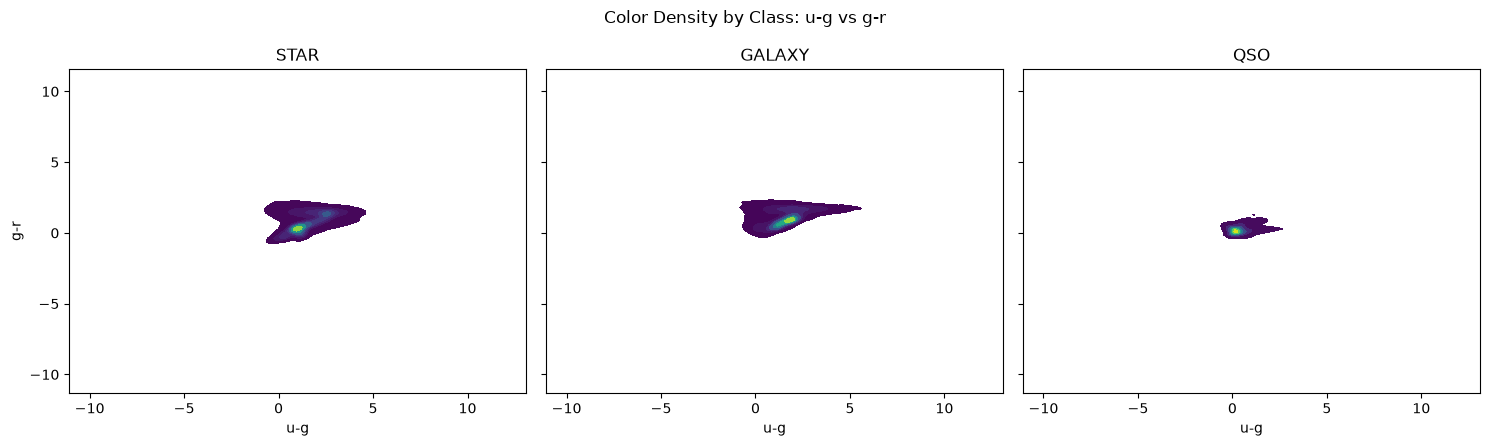

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)

for ax, cls in zip(axes, ["STAR", "GALAXY", "QSO"]):
    subset = density_sample[density_sample["object_class"] == cls]
    sns.kdeplot(
        data=subset, x="u_g", y="g_r",
        fill=True, cmap="viridis", thresh=0.05, levels=8, ax=ax
    )
    ax.set_title(cls)
    ax.set_xlabel("u-g")
    ax.set_ylabel("g-r")

plt.suptitle("Color Density by Class: u-g vs g-r")
plt.tight_layout()
plt.show()

##### Explanation
Viewed as density rather than raw points, STAR and GALAXY occupy nearly
identical regions in u-g/g-r space, their peak densities sit in almost the
same location. QSO's density is more compact and shifted slightly lower
(lower g-r), suggesting it has a somewhat distinct color signature, while
STAR and GALAXY remain difficult to separate using this color pair alone.

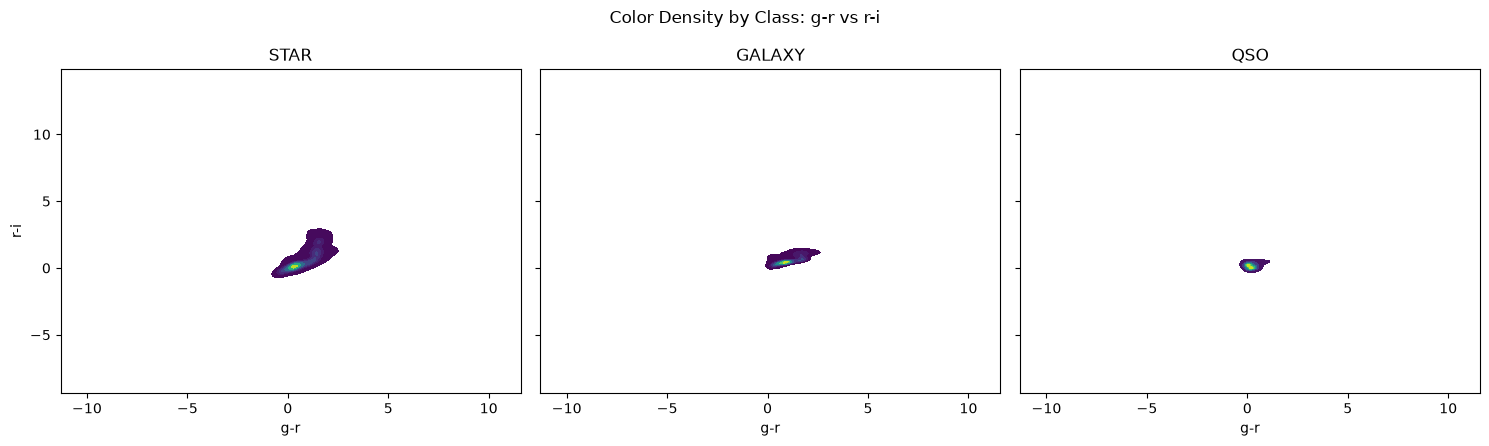

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)

for ax, cls in zip(axes, ["STAR", "GALAXY", "QSO"]):
    subset = density_sample[density_sample["object_class"] == cls]
    sns.kdeplot(
        data=subset, x="g_r", y="r_i",
        fill=True, cmap="viridis", thresh=0.05, levels=8, ax=ax
    )
    ax.set_title(cls)
    ax.set_xlabel("g-r")
    ax.set_ylabel("r-i")

plt.suptitle("Color Density by Class: g-r vs r-i")
plt.tight_layout()
plt.show()

##### Explanation
In g-r vs r-i space, STAR shows a distinct elongated tail extending toward
higher r-i values that GALAXY and QSO do not reach, while GALAXY's density is
more compact and shifted slightly lower. QSO remains extremely tight and
concentrated near the origin, more compact here than either STAR or GALAXY.

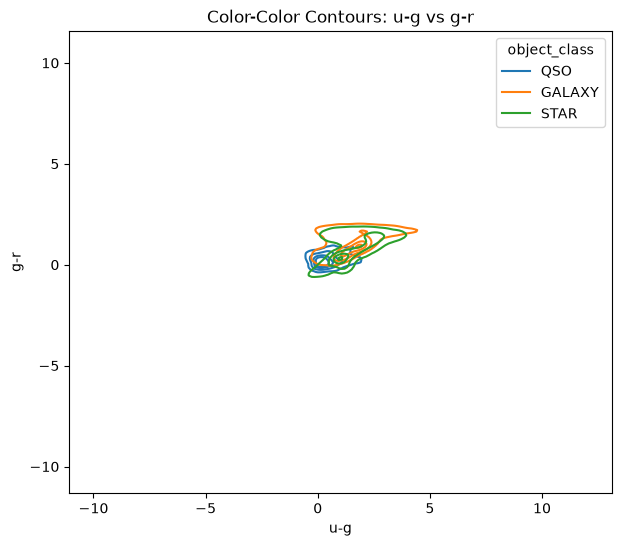

In [18]:
plt.figure(figsize=(7, 6))
sns.kdeplot(
    data=density_sample, x="u_g", y="g_r",
    hue="object_class", levels=5, thresh=0.1
)
plt.title("Color-Color Contours: u-g vs g-r")
plt.xlabel("u-g")
plt.ylabel("g-r")
plt.show()

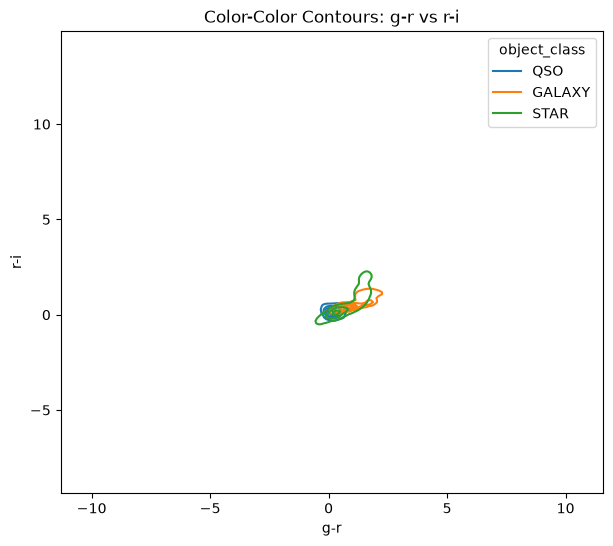

In [19]:
plt.figure(figsize=(7, 6))
sns.kdeplot(
    data=density_sample, x="g_r", y="r_i",
    hue="object_class", levels=5, thresh=0.1
)
plt.title("Color-Color Contours: g-r vs r-i")
plt.xlabel("g-r")
plt.ylabel("r-i")
plt.show()

##### Explanation
The overlay shows QSO and GALAXY cores overlapping substantially, while STAR's
contour extends into a region neither class occupies, the opposite pattern
from u-g vs g-r, where QSO was the class with a more distinct footprint. This
suggests different color pairs separate different class boundaries: u-g/g-r
helps isolate QSO, while g-r/r-i helps isolate STAR. Combining both pairs
(rather than relying on one) is likely necessary for a classifier to
distinguish all three classes.

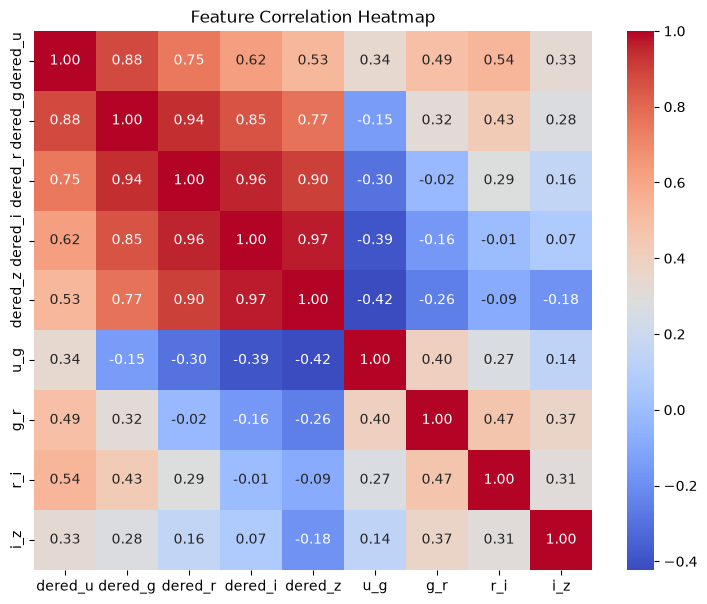

In [20]:
feature_cols = [
    "dered_u", "dered_g", "dered_r", "dered_i", "dered_z",
    "u_g", "g_r", "r_i", "i_z"
]

plt.figure(figsize=(9, 7))
sns.heatmap(df[feature_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

##### Explanation
Raw magnitudes are highly correlated with each other (0.53–0.97), indicating
redundant information, overall brightness dominates. Color indices show much
weaker correlation with raw magnitudes, confirming they capture distinct
information (spectral shape) rather than duplicating brightness.

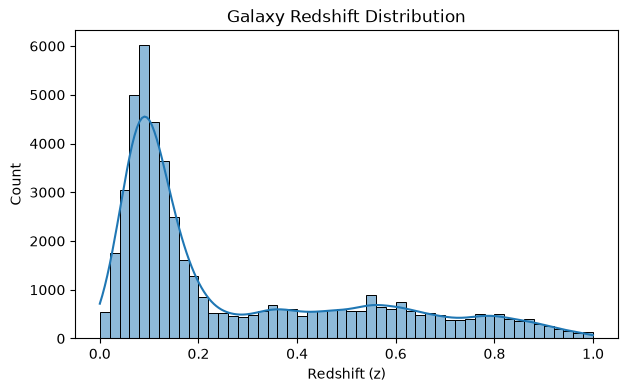

In [21]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df_galaxy, x="z", bins=50, kde=True)
plt.title("Galaxy Redshift Distribution")
plt.xlabel("Redshift (z)")
plt.ylabel("Count")
plt.show()

##### Explanation
The redshift distribution is heavily right-skewed: a sharp peak near z≈0.05 - 0.1,
with a long tail and a secondary bump around z≈0.55 - 0.6. This imbalance means
the regression model will see far more training examples at low redshift, so overall error metrics should be interpreted alongside error broken down by
redshift bin, not as a single summary number.

In [22]:
df_galaxy["z"].describe()

count    49402.000000
mean         0.275863
std          0.256418
min          0.000053
25%          0.084763
50%          0.142197
75%          0.455774
max          0.999834
Name: z, dtype: float64

In [23]:
df_galaxy["z"].quantile([0.01, 0.05, 0.5, 0.95, 0.99])

0.01    0.019181
0.05    0.041450
0.50    0.142197
0.95    0.813420
0.99    0.930890
Name: z, dtype: float64

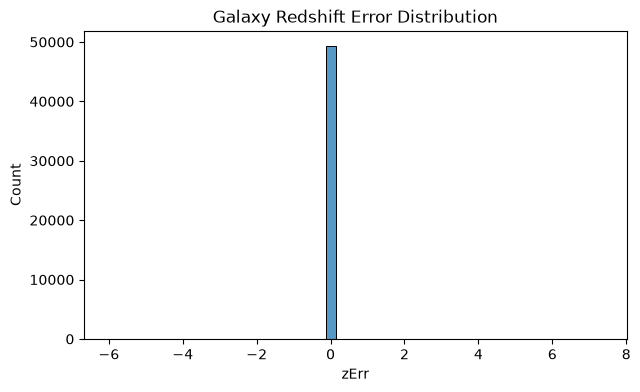

In [24]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df_galaxy, x="zErr", bins=50)
plt.title("Galaxy Redshift Error Distribution")
plt.xlabel("zErr")
plt.ylabel("Count")
plt.show()

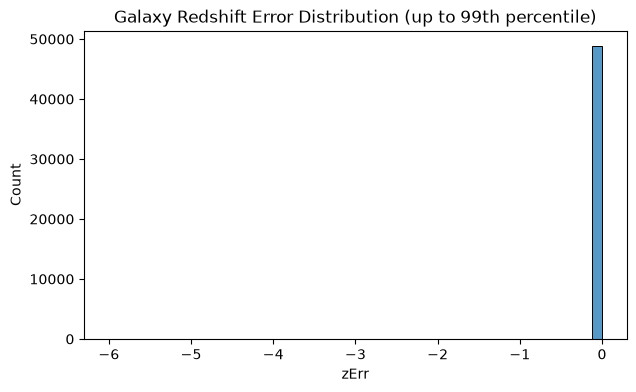

np.float64(0.0003671872509999996)

In [25]:
zerr_99 = df_galaxy["zErr"].quantile(0.99)

plt.figure(figsize=(7, 4))
sns.histplot(data=df_galaxy[df_galaxy["zErr"] <= zerr_99], x="zErr", bins=50)
plt.title("Galaxy Redshift Error Distribution (up to 99th percentile)")
plt.xlabel("zErr")
plt.ylabel("Count")
plt.show()

zerr_99

##### Explanation
Most galaxy redshift errors are already very small. The threshold check shows
that even a strict cutoff like `zErr <= 0.001` would keep almost all rows
(49,388 out of 49,402). This means the extreme `zErr` values exist, but only in
a very small number of rows.

For modeling, `zErr` filtering can be applied later with minimal data loss if
needed, but it should be documented as a quality-control decision rather than
silently applied during EDA.

In [26]:
color_cols = ["u_g", "g_r", "r_i", "i_z"]
galaxy_sample = df_galaxy.sample(min(150000, len(df_galaxy)), random_state=42)

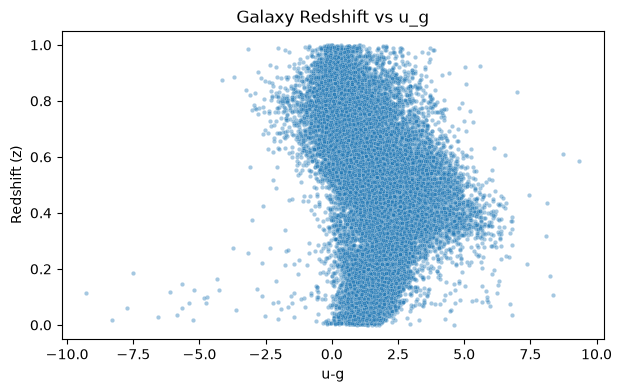

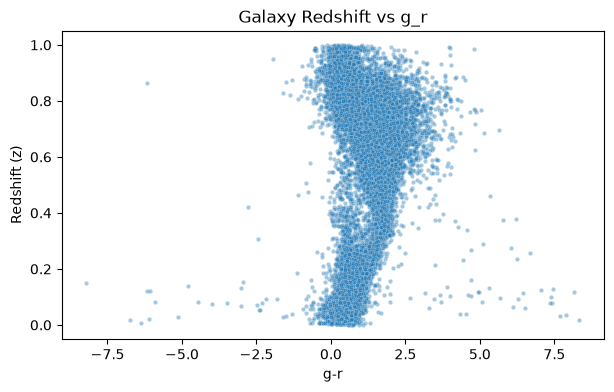

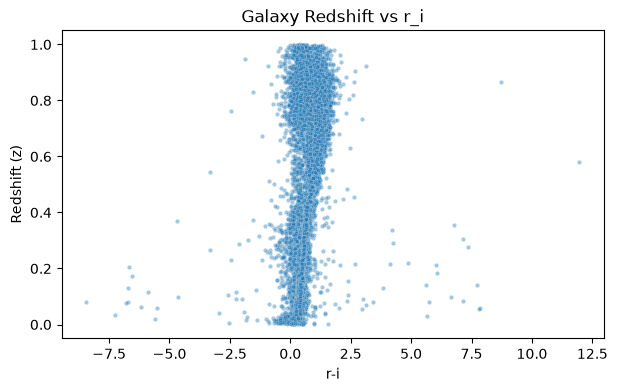

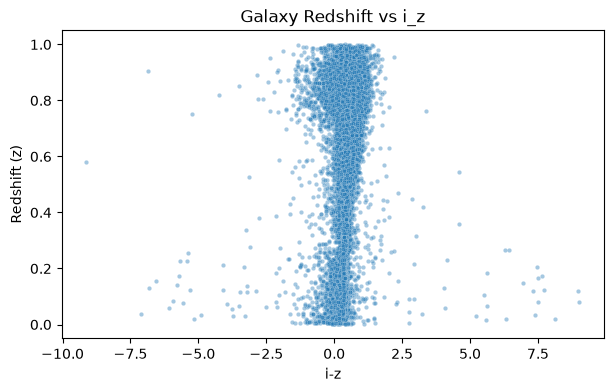

In [27]:
for col in color_cols:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(
        data=galaxy_sample,
        x=col,
        y="z",
        alpha=0.4,
        s=10
    )
    plt.title(f"Galaxy Redshift vs {col}")
    plt.xlabel(col.replace("_", "-"))
    plt.ylabel("Redshift (z)")
    plt.show()

##### Explanation
Across all four color indices, redshift shows no clear visual trend,  points
form a dense, roughly vertical band regardless of z, with sparse outliers
scattered across the full redshift range rather than concentrated at any
particular value. Color alone does not appear to carry strong predictive
signal for redshift.

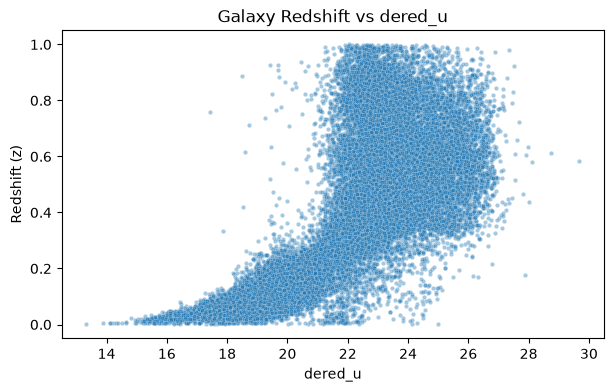

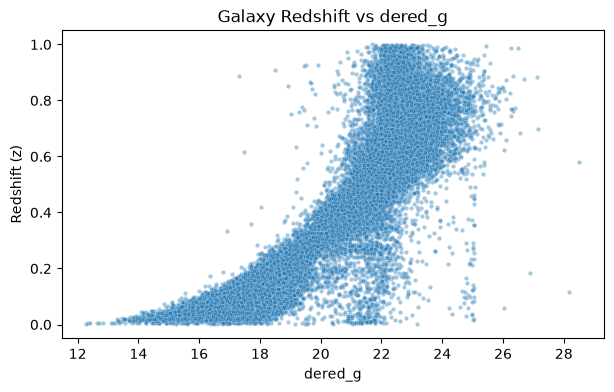

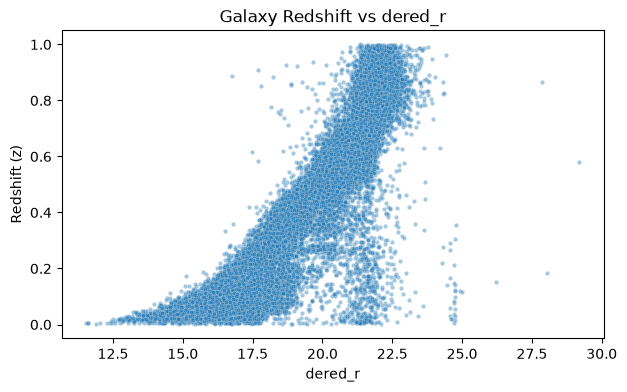

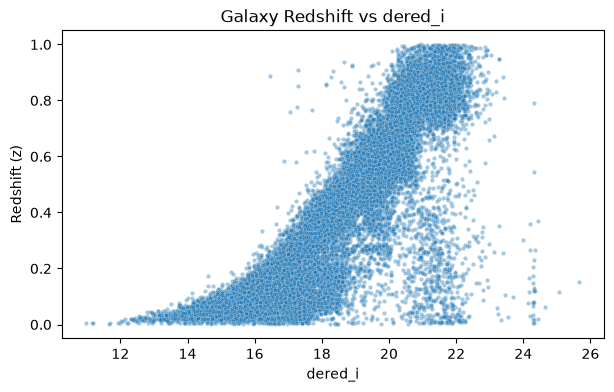

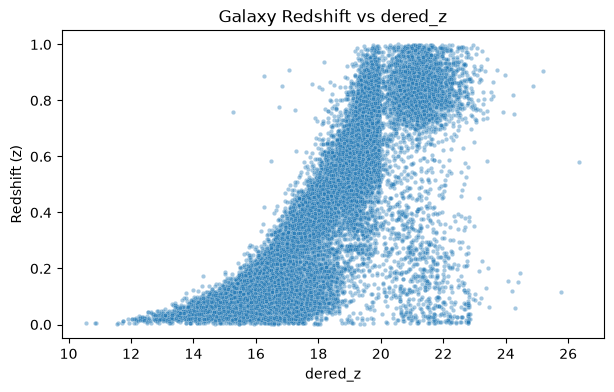

In [28]:
for col in mag_cols:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(
        data=galaxy_sample,
        x=col,
        y="z",
        alpha=0.4,
        s=10
    )
    plt.title(f"Galaxy Redshift vs {col}")
    plt.xlabel(col)
    plt.ylabel("Redshift (z)")
    plt.show()

##### Explanation
Unlike the color indices, all five raw magnitudes show a clear positive trend
with redshift: brighter (lower magnitude) galaxies cluster near z≈0, while
fainter galaxies extend toward higher z. This matches the expected
brightness-distance relationship, a galaxy of similar intrinsic luminosity
appears fainter the farther away it is. Raw magnitude looks like a stronger
visual predictor for this regression task than color index, the opposite of
what was seen for classification, where color carried more of the separating
signal.

dered_z also shows a denser secondary cluster around magnitude ~19–20 at
z≈0.8–1.0, possibly reflecting a specific targeted subset within the SDSS
galaxy sample rather than a general population trend, though confirming this
would need further investigation.

In [29]:
galaxy_corr_cols = feature_cols + ["z", "zErr"]

df_galaxy[galaxy_corr_cols].corr()["z"].sort_values(ascending=False)

z          1.000000
dered_g    0.909240
dered_r    0.905975
dered_i    0.876638
dered_z    0.848592
dered_u    0.815855
r_i        0.645736
g_r        0.424158
i_z        0.303065
zErr       0.003359
u_g       -0.198611
Name: z, dtype: float64

##### Explanation
Correlation with `z` confirms the visual pattern from the scatter plots: raw
magnitudes (0.82–0.91) are far more predictive of redshift than color indices
(0.30–0.65, with u_g even slightly negative). Magnitude should be the primary
feature set for the regression task.

In [30]:
thresholds = [0.001, 0.005, 0.01, 0.05, 0.1]

for threshold in thresholds:
    kept = (df_galaxy["zErr"] <= threshold).sum()
    total = len(df_galaxy)
    print(f"zErr <= {threshold}: keeps {kept:,} / {total:,} rows ({kept / total:.2%})")

zErr <= 0.001: keeps 49,388 / 49,402 rows (99.97%)
zErr <= 0.005: keeps 49,388 / 49,402 rows (99.97%)
zErr <= 0.01: keeps 49,389 / 49,402 rows (99.97%)
zErr <= 0.05: keeps 49,390 / 49,402 rows (99.98%)
zErr <= 0.1: keeps 49,392 / 49,402 rows (99.98%)


##### Explanation
The zErr threshold table resolves the filtering question deferred from
notebook 02: over 99.97% of galaxy rows already have zErr <= 0.001, meaning
only ~14 rows are extreme outliers. The zWarning == 0 filter applied at the
SQL query stage appears to have already removed unreliable measurements, no
additional zErr filtering is necessary, though a light cutoff (zErr <= 0.01)
could be applied as a safety margin at negligible cost (~13 rows).

## EDA Notes

The classification task looks like it will need multiple color features, not
just one color-color pair. In `u_g` vs `g_r`, QSO separates more clearly, while
STAR and GALAXY overlap heavily. In `g_r` vs `r_i`, STAR becomes more distinct,
so combining several color indices should help the classifier.

For redshift regression, raw magnitudes show stronger visual and correlation
signal than color indices alone. The target distribution is also imbalanced,
with many low-redshift galaxies and fewer high-redshift galaxies, so later
evaluation should include error by redshift range instead of relying only on
one overall score.

`zErr` has a few extreme values, but strict thresholds would remove very few
rows. Any `zErr` filtering should be treated as a documented quality-control
choice in the modeling phase, not something hidden inside EDA.